In [1]:
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

import matplotlib.pyplot as plt

In [2]:
train = pd.read_csv("../datasets/liar_dataset/train.csv")
valid = pd.read_csv("../datasets/liar_dataset/valid.csv")
test = pd.read_csv("../datasets/liar_dataset/test.csv")

In [3]:
print("Train:", train.shape)
print("Validation:", valid.shape)
print("Test:", test.shape)

Train: (10269, 14)
Validation: (1284, 14)
Test: (1283, 14)


In [4]:
print(train.columns.tolist())

['id', 'label', 'statement', 'subject', 'speaker', 'speaker_job_title', 'state_info', 'party_affiliation', 'barely_true_counts', 'false_counts', 'half_true_counts', 'mostly_true_counts', 'pants_on_fire_counts', 'context']


In [5]:
print(train["statement"].isna().sum())
print(valid["statement"].isna().sum())
print(test["statement"].isna().sum())

0
0
0


In [6]:
print(train["label"].isna().sum())
print(valid["label"].isna().sum())
print(test["label"].isna().sum())

0
0
0


In [7]:
print(train["label"].value_counts())

label
half-true      2123
false          1998
mostly-true    1966
true           1683
barely-true    1657
pants-fire      842
Name: count, dtype: int64


# minimal cleaning at this stage

In [8]:
def clean_text(text):
    text = str(text)
    text = text.strip()
    text = " ".join(text.split())
    
    return text

In [9]:
train["clean_statement"] = train["statement"].apply(clean_text)
valid["clean_statement"] = valid["statement"].apply(clean_text)
test["clean_statement"] = test["statement"].apply(clean_text)

In [10]:
X_train = train["clean_statement"]
y_train = train["label"]

X_valid = valid["clean_statement"]
y_valid = valid["label"]

X_test = test["clean_statement"]
y_test = test["label"]

In [11]:
baseline_model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.95,
            sublinear_tf=True
        )
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=2000
        )
    )
])

# training first model

In [12]:
baseline_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


In [13]:
y_valid_pred = baseline_model.predict(X_valid)

In [14]:
valid_accuracy = accuracy_score(y_valid, y_valid_pred)

print("Validation Accuracy:", valid_accuracy)

Validation Accuracy: 0.2601246105919003


In [15]:
valid_f1 = f1_score(
    y_valid,
    y_valid_pred,
    average="macro"
)

print("Validation Macro F1:", valid_f1)

Validation Macro F1: 0.23782120212513855


In [16]:
print("Validation Accuracy:", accuracy_score(y_valid, y_valid_pred))
print("Validation Macro F1:", f1_score(y_valid, y_valid_pred, average="macro"))

print(classification_report(y_valid, y_valid_pred))

Validation Accuracy: 0.2601246105919003
Validation Macro F1: 0.23782120212513855
              precision    recall  f1-score   support

 barely-true       0.25      0.18      0.21       237
       false       0.28      0.33      0.30       263
   half-true       0.25      0.37      0.30       248
 mostly-true       0.28      0.27      0.27       251
  pants-fire       0.45      0.08      0.13       116
        true       0.21      0.21      0.21       169

    accuracy                           0.26      1284
   macro avg       0.29      0.24      0.24      1284
weighted avg       0.27      0.26      0.25      1284



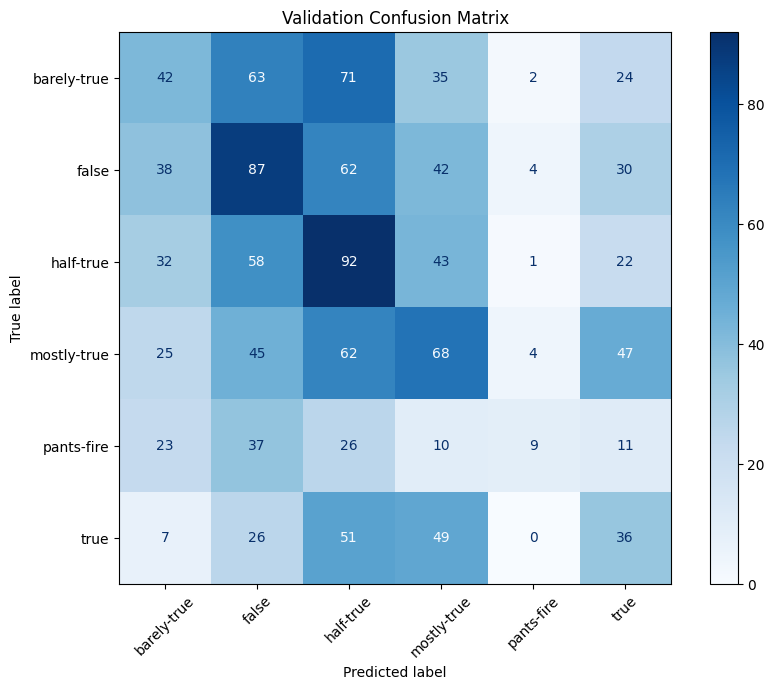

In [17]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 7))

ConfusionMatrixDisplay.from_predictions(
    y_valid,
    y_valid_pred,
    xticks_rotation=45,
    cmap="Blues",
    ax=ax
)

plt.title("Validation Confusion Matrix")
plt.tight_layout()
plt.show()

In [19]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(baseline_model, "../models/baseline_model.pkl")

['../models/baseline_model.pkl']